# Churn Prediction Project

## Importing Libraries & Reading Data

In [146]:
# importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, classification_report
import joblib

In [62]:
# reading data file
df = pd.read_csv('customer_churn.csv')
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49.0,Male,4.0,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43.0,Male,0.0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51.0,Female,2.0,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60.0,Female,8.0,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42.0,Male,32.0,69.01,Month-to-Month,NaN,2208.32,No,Yes


## Cleaning & EDA

In [63]:
df.shape

(1300, 10)

In [67]:
df.describe()

,Age,Tenure,MonthlyCharges,TotalCharges
count,1300.000000,1300.000000,1300.000000,1300.000000
mean,44.803413,19.102543,74.533297,1417.927598
std,9.879719,18.312632,25.307005,1534.295846
min,12.000000,0.000000,23.588622,-8.125862
25%,38.000000,5.248210,53.807500,348.626213
50%,45.000000,14.000000,74.005000,935.685000
75%,51.000000,28.000000,94.450000,1952.380255
max,83.000000,122.000000,143.789767,12416.250000


In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       1300 non-null   object 
 1   Age              1300 non-null   float64
 2   Gender           1300 non-null   object 
 3   Tenure           1300 non-null   float64
 4   MonthlyCharges   1300 non-null   float64
 5   ContractType     1300 non-null   object 
 6   InternetService  1003 non-null   object 
 7   TotalCharges     1300 non-null   float64
 8   TechSupport      1300 non-null   object 
 9   Churn            1300 non-null   object 
dtypes: float64(4), object(6)
memory usage: 101.7+ KB


In [161]:
# checking for duplicates
df.duplicated().sum()

0

In [163]:
# checking for missing values
df.isnull().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
MonthlyCharges       0
ContractType         0
InternetService    297
TotalCharges         0
TechSupport          0
Churn                0
dtype: int64

In [165]:
# filling missing values with "Unknown" category
churn_df = df.copy()
churn_df['InternetService'] = churn_df['InternetService'].fillna('Unknown')
churn_df.isnull().sum()

CustomerID         0
Age                0
Gender             0
Tenure             0
MonthlyCharges     0
ContractType       0
InternetService    0
TotalCharges       0
TechSupport        0
Churn              0
dtype: int64

In [73]:
churn_df['Churn'].value_counts()

Churn
Yes    1142
No      158
Name: count, dtype: int64

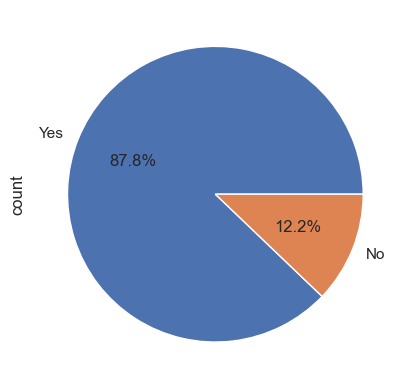

In [167]:
# checking for dataset imbalance
churn_df['Churn'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.show()

In [75]:
churn_df['ContractType'].value_counts()

ContractType
Month-to-Month    669
One-Year          365
Two-Year          266
Name: count, dtype: int64

In [76]:
churn_df['InternetService'].value_counts()

InternetService
Fiber Optic    571
DSL            432
Unknown        297
Name: count, dtype: int64

In [173]:
# average monthly charges & tenure for each churn-gender type
churn_df.groupby(['Churn', 'Gender'])[['MonthlyCharges', 'Tenure']].mean()

MonthlyCharges     Tenure
Churn Gender                           
No    Female       68.846222  27.519956
      Male         62.009968  27.303065
Yes   Female       75.150032  17.609577
      Male         76.383269  18.331765

In [171]:
# average age by churn type
churn_df.groupby('Churn')['Age'].mean()

Churn
No     43.862299
Yes    44.933620
Name: Age, dtype: float64

In [175]:
# average monthly charges by contract type
churn_df.groupby('ContractType')['MonthlyCharges'].mean()

ContractType
Month-to-Month    76.246639
One-Year          73.380191
Two-Year          71.806446
Name: MonthlyCharges, dtype: float64

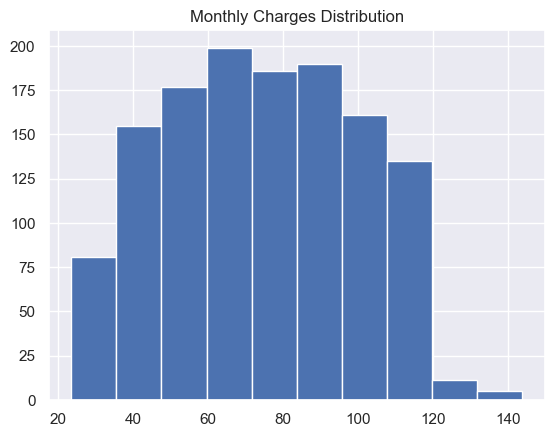

In [183]:
# plotting monthly charges distribution
plt.hist(churn_df['MonthlyCharges'])
plt.title('Monthly Charges Distribution')
plt.show()

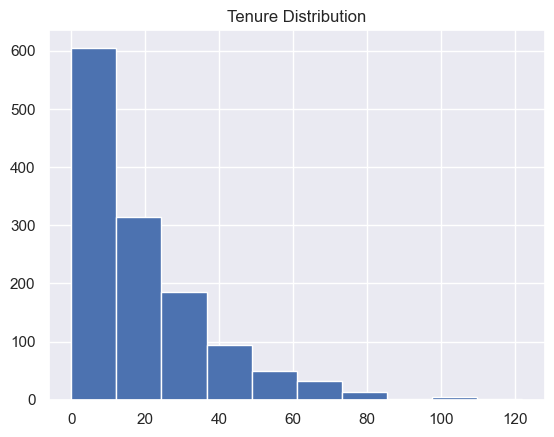

In [181]:
# plotting tenure distribution
plt.hist(churn_df['Tenure'])
plt.title('Tenure Distribution')
plt.show()

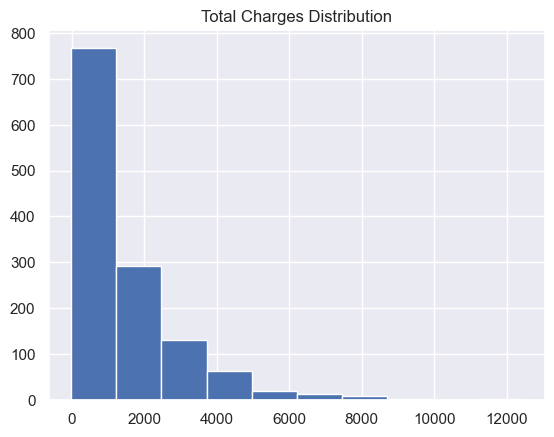

In [179]:
# plotting total charges distribution
plt.hist(churn_df['TotalCharges'])
plt.title('Total Charges Distribution')
plt.show()

In [185]:
# dataframe for only numeric columns to analyze correlations
numeric_df = churn_df.select_dtypes(include=['int', 'float'])
numeric_df.head()

,Age,Tenure,MonthlyCharges,TotalCharges
0,49.0,4.0,88.35,353.40
1,43.0,0.0,36.67,0.00
2,51.0,2.0,63.79,127.58
3,60.0,8.0,102.34,818.72
4,42.0,32.0,69.01,2208.32


<Axes: >

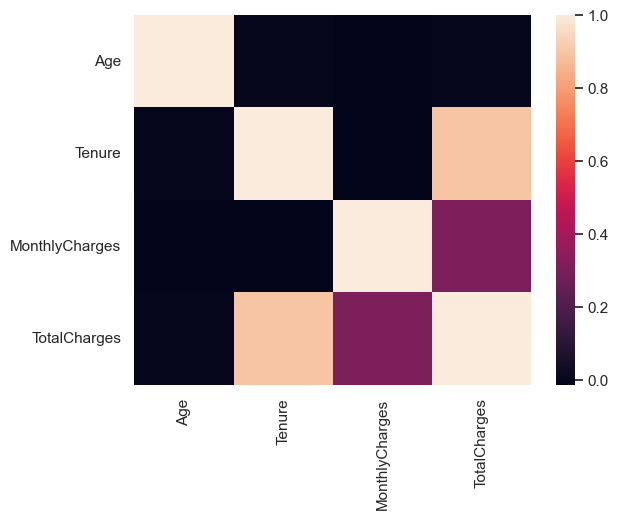

In [187]:
# inspecting correlations
sns.heatmap(numeric_df.corr())

## Model Building

In [101]:
churn_df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49.0,Male,4.0,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43.0,Male,0.0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51.0,Female,2.0,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60.0,Female,8.0,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42.0,Male,32.0,69.01,Month-to-Month,Unknown,2208.32,No,Yes


In [189]:
# splitting feature and target variables
X = churn_df[['Age', 'Gender', 'Tenure', 'MonthlyCharges', 'ContractType', 'InternetService', 'TechSupport']]
y = churn_df['Churn']

In [191]:
# label encoding the target variable
le = LabelEncoder()
y = le.fit_transform(y)

In [193]:
# splitting to training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [195]:
# composing transformation pipelines for each feature type
numerical_features = ['Age', 'Tenure', 'MonthlyCharges']
categorical_features = ['Gender', 'ContractType', 'InternetService', 'TechSupport']

numerical_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('ohe', OneHotEncoder(drop='first', sparse_output=False).set_output(transform='pandas'))
])

In [197]:
# constructing column transformer for parallel processing the transformation pipelines
preprocessor = ColumnTransformer([
    ('numerical', numerical_pipeline, numerical_features),
    ('categorical', categorical_pipeline, categorical_features)
])

In [201]:
# models for best model selection
models = {
    'logistic regression': LogisticRegression(),
    'svm': SVC(),
    'random forest': RandomForestClassifier(),
    'xgb': XGBClassifier()
}

In [203]:
# parameter hyper tuning for each model
parameters = {
    'logistic regression': [{
        'model__C': [0.01, 0.1, 1, 10, 100],
        'model__penalty': [None, 'l2'],
        'model__solver': ['lbfgs'],
        'model__max_iter': [1000],
        'model__class_weight': ['balanced']
    },{
        'model__C': [0.01, 0.1, 1, 10, 100],
        'model__penalty': ['l1', 'l2'],
        'model__solver': ['liblinear'],
        'model__max_iter': [1000],
        'model__class_weight': ['balanced']
    }],
    'svm': {
        'model__C': [0.01, 0.1, 1, 10, 100],
        'model__kernel': ['linear', 'rbf', 'poly'],
        'model__class_weight': ['balanced']
    },
    'random forest': {
        'model__n_estimators': [100, 200],
        'model__max_depth': [3, 5],
        'model__min_samples_split': [5, 10],
        'model__min_samples_leaf': [2, 4],
        'model__max_features': ['sqrt', 'log2'],
        'model__class_weight': ['balanced']
    },
    'xgb': {
        'model__n_estimators': [100, 200],
        'model__max_depth': [3, 5],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__subsample': [0.7, 0.8, 0.9],
        'model__colsample_bytree': [0.7, 0.8, 0.9],
        'model__gamma': [0, 0.1, 0.3]
    }
}

In [205]:
# composing pipelines for each model
pipelines = {
    name: Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    for name, model in models.items()
}

In [207]:
# cv strategy using Stratified K-Fold to ensure balance
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [209]:
# running GridSearchCV to use cross-validation to find the model with the best performance on training data

In [125]:
best_models = {}
for model in models.keys():
    gs = GridSearchCV(estimator=pipelines[model], param_grid=parameters[model], cv=cv_strategy, scoring='f1', n_jobs=-1)
    gs.fit(X_train, y_train)
    best_models[model] = gs

In [211]:
# best parameter tuning for each model type
for model, gs in best_models.items():
    print(model, gs.best_params_, gs.best_score_)

logistic regression {'model__C': 1, 'model__class_weight': 'balanced', 'model__max_iter': 1000, 'model__penalty': 'l2', 'model__solver': 'lbfgs'} 0.8451140816820375
svm {'model__C': 0.01, 'model__class_weight': 'balanced', 'model__kernel': 'poly'} 0.9301146400809112
random forest {'model__class_weight': 'balanced', 'model__max_depth': 5, 'model__max_features': 'log2', 'model__min_samples_leaf': 4, 'model__min_samples_split': 10, 'model__n_estimators': 200} 0.933137970718561
xgb {'model__colsample_bytree': 0.8, 'model__gamma': 0.1, 'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 100, 'model__subsample': 0.7} 0.9626849191025645


In [213]:
# model with the best performance
best_score = -1
for model, gs in best_models.items():
    if gs.best_score_ > best_score:
        best_score = gs.best_score_
        best_model = gs.best_estimator_
print(best_model, best_score)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Tenure',
                                                   'MonthlyCharges']),
                                                 ('categorical',
                                                  Pipeline(steps=[('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 sparse_output=False))]),
                                                  ['Gender', 'ContractType',
                                                   'InternetService',
                                                   'TechSupport'])])),
                ('model',
                

In [215]:
# performance score of the best model on the test data
y_pred = best_model.predict(X_test)
f1_score(y_test, y_pred)

0.9715536105032823

In [229]:
# model classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.78      0.79        32
           1       0.97      0.97      0.97       228

    accuracy                           0.95       260
   macro avg       0.89      0.88      0.88       260
weighted avg       0.95      0.95      0.95       260



## Model Storing

In [225]:
# saving best model
joblib.dump(best_model, 'churn_pipeline.pkl')

['churn_pipeline.pkl']